# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
!pip install astroquery
from astroquery.sdss import SDSS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.9 MB/s eta 0:00:00


# Loading in Galaxy Sample

In [3]:
url = "https://raw.githubusercontent.com/cthitch137/Galaxy-Population-Study/refs/heads/main/galaxy_sample.csv"
df = pd.read_csv(url)

In [4]:
df

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian,low_z
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.20291,True
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.13883,False
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,13.57714,False
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,16.28147,False
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.06976,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1742,1237657630064771164,180.024895,52.856926,7.255751,0.066559,GALAXY,17.00500,15.86378,15.29716,14.88341,14.74320,27.81766,True
1743,1237657630064836760,180.184383,52.915778,4.151716,0.062125,GALAXY,18.83415,17.68426,17.19932,16.86122,16.67442,15.46933,True
1744,1237657630064967752,180.694067,53.037893,6.406927,0.062437,GALAXY,18.59546,17.32973,16.74337,16.38386,16.18288,12.43912,True
1745,1237657630067064939,188.650746,52.997370,4.636442,0.077760,GALAXY,19.26814,17.34073,16.43362,16.01825,15.72160,18.99535,True


---
## Pulling emission line data from SDSS for BPT classification

We're looking to pull four emission lines from SDSS: **[OIII], Hβ, [NII], Hα**.

By taking the ratio of the lines (OIII/Hβ and NII/Hα), we can tell what is ionizing the gas in a galaxy. When looking for AGNs, their high energy ionization produces different ratios than those from young hot stars in star forming regions.



In [35]:
query = f"""
SELECT TOP 10000
  s.bestObjID as objid,
  g.oiii_5007_flux, g.oiii_5007_flux_err,
  g.h_beta_flux, g.h_beta_flux_err,
  g.nii_6584_flux, g.nii_6584_flux_err,
  g.h_alpha_flux, g.h_alpha_flux_err
FROM galSpecLine g
JOIN SpecObj s ON g.specobjid = s.specobjid
WHERE s.z BETWEEN 0.02 AND 0.25
AND s.class = 'GALAXY'
AND s.sciencePrimary = 1
"""

result = SDSS.query_sql(query)
df_lines = result.to_pandas()

df_bpt = df.merge(df_lines, on='objid', how='inner')
df_bpt = df_bpt.drop_duplicates(subset='objid', keep='first')
df_bpt = df_bpt.reset_index(drop=True)
print(f"Galaxies with emission line data: {len(df_bpt)}")


Galaxies with emission line data: 736


In [36]:
df_bpt

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,...,snMedian,low_z,oiii_5007_flux,oiii_5007_flux_err,h_beta_flux,h_beta_flux_err,nii_6584_flux,nii_6584_flux_err,h_alpha_flux,h_alpha_flux_err
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,...,10.20291,True,0.486909,1.677912,4.143331,2.936817,3.431805,2.359388,5.432809,4.066201
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,...,11.13883,False,0.486909,1.677912,4.143331,2.936817,3.431805,2.359388,5.432809,4.066201
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,...,13.57714,False,2.290993,1.782485,2.684766,1.743213,3.015994,1.634863,6.958476,1.832807
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,...,16.28147,False,2.290993,1.782485,2.684766,1.743213,3.015994,1.634863,6.958476,1.832807
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,...,11.06976,True,12.127970,2.958894,2.808195,6.919081,0.449470,2.387792,0.432772,5.583998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,1237654670272823422,150.782687,0.045169,7.964827,0.067347,GALAXY,17.59971,15.61741,14.72970,14.33366,...,35.18884,True,27.934880,8.054743,18.896560,7.461865,49.540720,9.626809,42.234080,9.932669
732,1237654670272823491,150.836059,0.010338,5.932590,0.059905,GALAXY,19.09027,17.81338,17.21082,16.86208,...,11.17190,True,21.412670,4.298555,19.012630,4.148290,59.521100,5.541990,53.562160,5.569401
733,1237654670272823538,150.893369,0.076012,6.009070,0.066875,GALAXY,18.89589,16.94037,15.92199,15.43285,...,21.15041,True,21.412670,4.298555,19.012630,4.148290,59.521100,5.541990,53.562160,5.569401
734,1237654670272888852,150.939444,0.029950,4.613786,0.066054,GALAXY,19.05579,17.00594,16.08009,15.64406,...,25.68167,True,19.677480,5.108365,27.689110,5.894341,18.840100,5.179586,32.875130,6.411029


In [37]:
print(f"Full sample: {len(df)}")
print(f"Galaxies with emission line data: {len(df_bpt)}")
print(f"Fraction of full sample with emission lines: {len(df_bpt)/len(df):.2f}")

Full sample: 1747
Galaxies with emission line data: 736
Fraction of full sample with emission lines: 0.42


In [39]:
sn_cut = (
    (df_bpt['oiii_5007_flux'] / df_bpt['oiii_5007_flux_err'] > 3) &
    (df_bpt['h_beta_flux'] / df_bpt['h_beta_flux_err'] > 3) &
    (df_bpt['nii_6584_flux'] / df_bpt['nii_6584_flux_err'] > 3) &
    (df_bpt['h_alpha_flux'] / df_bpt['h_alpha_flux_err'] > 3)
)

df_bpt[sn_cut]

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,...,snMedian,low_z,oiii_5007_flux,oiii_5007_flux_err,h_beta_flux,h_beta_flux_err,nii_6584_flux,nii_6584_flux_err,h_alpha_flux,h_alpha_flux_err
6,1237648720145613050,153.965614,-0.974097,5.108194,0.070222,GALAXY,18.73285,17.45038,16.85139,16.46405,...,16.49333,True,8.618657,2.340734,61.345410,2.513215,86.58823,2.620798,256.79440,3.565483
7,1237648720145940778,154.825418,-0.865715,3.627925,0.093317,GALAXY,19.87001,17.90517,16.93169,16.49078,...,17.24009,True,17.363250,3.735895,21.915570,3.751601,61.55126,4.236951,52.70899,4.369156
9,1237648720146137238,155.185374,-0.979828,5.415997,0.084116,GALAXY,18.84252,17.72303,17.26807,16.93408,...,13.40524,True,7.229552,2.193208,19.655740,2.171456,27.89749,1.923929,63.14137,2.265139
10,1237648720146137296,155.244116,-0.899464,4.295741,0.101157,GALAXY,20.67787,18.69186,17.73617,17.29178,...,12.34907,False,7.229552,2.193208,19.655740,2.171456,27.89749,1.923929,63.14137,2.265139
11,1237648720678944894,145.874449,-0.608755,9.828067,0.071590,GALAXY,18.19744,16.69651,16.01479,15.64210,...,15.69197,True,10.249010,2.229021,21.083220,2.107408,34.42918,2.208707,97.32662,2.600087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1237654669735035113,148.706786,-0.344655,5.489245,0.164711,GALAXY,20.07428,18.50792,17.41413,16.91184,...,11.22781,False,8.844413,2.822858,7.305626,2.076149,22.67718,2.635267,35.12659,2.911951
727,1237654669735166231,149.105307,-0.367428,3.949292,0.090887,GALAXY,20.24663,18.22563,17.28766,16.86633,...,12.74358,True,10.188780,3.168770,9.005432,2.252380,29.86841,2.638283,45.66881,2.525214
732,1237654670272823491,150.836059,0.010338,5.932590,0.059905,GALAXY,19.09027,17.81338,17.21082,16.86208,...,11.17190,True,21.412670,4.298555,19.012630,4.148290,59.52110,5.541990,53.56216,5.569401
733,1237654670272823538,150.893369,0.076012,6.009070,0.066875,GALAXY,18.89589,16.94037,15.92199,15.43285,...,21.15041,True,21.412670,4.298555,19.012630,4.148290,59.52110,5.541990,53.56216,5.569401


In [60]:
df_bpt['nii/hα'] = df_bpt['nii_6584_flux'] / df_bpt['h_alpha_flux']
df_bpt['oiii/hβ'] = df_bpt['oiii_5007_flux'] / df_bpt['h_beta_flux']

Text(0, 0.5, '$\\log_{10}(\\text{[OIII]} \\, \\lambda \\, 5007 \\text{/Hβ})$')

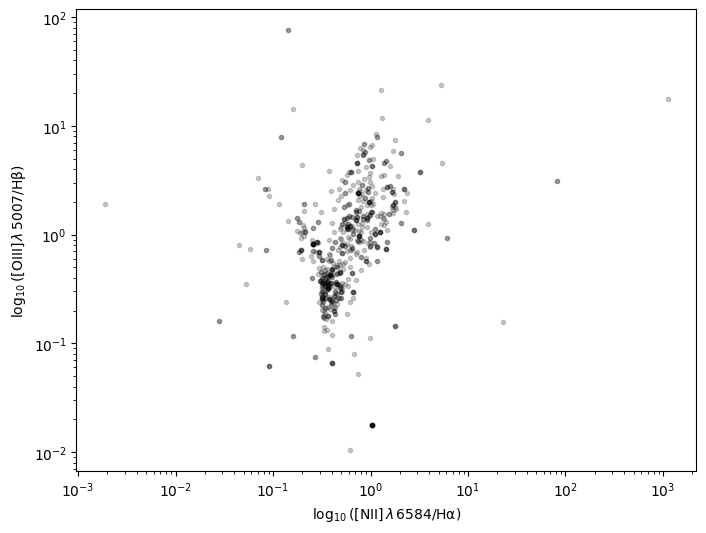

In [78]:


plt.figure(figsize=(8,6))
plt.plot(df_bpt['nii/hα'], df_bpt['oiii/hβ'], 'k.', alpha=0.2)
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\log_{10}(\text{[NII]} \, \lambda \, 6584 \text{/Hα})$')
plt.ylabel(r'$\log_{10}(\text{[OIII]} \, \lambda \, 5007 \text{/Hβ})$')
